# Lab 2: Predictive Analytics with Machine Learning

**Duration:** 2 weeks [18 Jun - 25 Jun, 2026]
**Due Date:** 25th June, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** [Enter Name]
**Student ID:** [Enter ID]

---

### Objective

In this lab you will run a complete machine-learning workflow on **two real tabular datasets**,
covering both **supervised** and **unsupervised** learning:

| #   | Task                           | Dataset                          | Type         | Target                    |
| --- | ------------------------------ | -------------------------------- | ------------ | ------------------------- |
| 1   | **Regression**                 | NYC Yellow Taxi trips            | Supervised   | `tip_amount` (continuous) |
| 2   | **Multi-class classification** | Obesity-level prediction         | Supervised   | `NObeyesdad` (7 classes)  |
| 3   | **Clustering (K-Means)**       | Obesity features (labels hidden) | Unsupervised | discover patient groups   |

Along the way you will practise **NumPy, Pandas, and scikit-learn** to load and explore data,
clean and preprocess it, engineer features, split it into **train / validation / test** sets,
train models, **check for overfitting**, and discover hidden structure with clustering.

> **Note:** In this lab your _reasoning_ is graded just as heavily as your _code_. Every section
> ends with a **Student Reasoning** box — fill it in with full sentences that justify your choices.

### Topics covered

Supervised learning (regression & classification), unsupervised learning (K-Means clustering),
feature engineering, train/validation/test splits, model evaluation, and overfitting.


---

### Part 0: Repository Setup _(done outside this notebook)_

1. Create a **public** repository named `lab-2-predictive-analytics` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_2_predictive_analytics.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas scikit-learn matplotlib seaborn`.
5. Commit and push your finished, fully-run notebook at the end.

**Local setup**

```bash
python -m venv .venv
source .venv/bin/activate        # Windows: .venv\Scripts\activate
pip install -r requirements.txt
jupyter lab
```

Open a new notebook, rename it, and run the cells below directly
(the datasets are loaded straight from their URLs, so no Drive mount is required).


In [ ]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42  # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"


---

# Section 1 — Supervised Learning: Regression

## Predicting taxi `tip_amount` (NYC Yellow Taxi)

Each row is a completed taxi trip. Your goal is to **predict the tip a passenger leaves**
(`tip_amount`, a continuous value) from the trip's characteristics. The available columns are:

`VendorID, passenger_count, trip_distance, RatecodeID, store_and_fwd_flag, PULocationID,
DOLocationID, payment_type, fare_amount, mta_tax, tolls_amount, improvement_surcharge, tip_amount`


### Part 1.1 — Load and explore the taxi data

Understand the shape, the data types, missing values, and the distribution of the target.


(41202, 13)
   VendorID  passenger_count  trip_distance  RatecodeID  store_and_fwd_flag  \
0         2                1          17.63           2                   1   
1         2                1          19.52           2                   1   
2         2                1          17.81           2                   1   
3         2                2          19.30           2                   1   
4         2                1          18.75           2                   1   

   PULocationID  DOLocationID  payment_type  fare_amount  mta_tax  \
0           132           164             1         70.0      0.5   
1           132           236             1         70.0      0.5   
2           132            48             1         70.0      0.5   
3           132           148             1         70.0      0.5   
4           132           234             1         70.0      0.5   

   tolls_amount  improvement_surcharge  tip_amount  
0          6.94                      1       

<Axes: xlabel='tip_amount', ylabel='Count'>

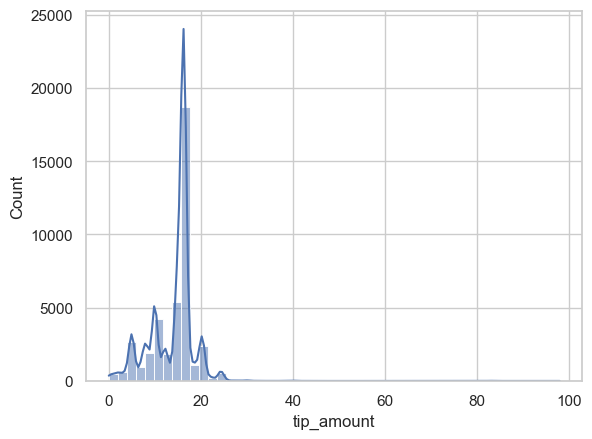

In [8]:
# TODO: Load the taxi dataset from TAXI_URL into a DataFrame called `taxi`
taxi = pd.read_csv(TAXI_URL)

# TODO: Inspect it
# - taxi.shape, taxi.head(), taxi.info()
# - taxi.describe()
# - count missing values per column: taxi.isna().sum()

print(taxi.shape)
print(taxi.head())
print(taxi.info())
print(taxi.describe())
print(taxi.isna().sum())

# TODO: Visualise the distribution of the target `tip_amount`
#   (e.g. sns.histplot). Comment on its shape and any extreme values.
sns.histplot(data=taxi, x="tip_amount", bins=50, kde=True)

**Student Reasoning — Taxi data exploration**
_What is the shape of the data? Are there missing values or impossible values
(e.g. negative tips, zero-distance trips)? What does the `tip_amount` distribution look like
(skew, outliers, many zeros)? How will this influence your preprocessing?_

The data is a left-skewed distribution with a roughly estimated mean tip amount of 16. There are no missing values.

> **Answer:** [Double-click to edit]


### Part 1.2 — Preprocessing & feature engineering

Clean the data and create features that help predict the tip.


In [ ]:
# TODO: Handle missing / invalid rows
#   e.g. drop or impute NaNs; remove rows where trip_distance <= 0 or fare_amount <= 0;
#   decide how to treat negative tip_amount values.
new_taxi = taxi.copy()
new_taxi = taxi.dropna()
new_taxi = new_taxi[
    (new_taxi["trip_distance"] > 0)
    & (new_taxi["fare_amount"] > 0)
    & (new_taxi["tip_amount"] >= 0)
].copy()
# TODO: Feature engineering — create at least ONE new, justified feature, for example:
#   - tip_rate proxy, fare-per-mile = fare_amount / trip_distance
#   - total surcharges = mta_tax + tolls_amount + improvement_surcharge
#   (Careful: do NOT leak the target. Do not build features directly from tip_amount.)
new_taxi["fare_per_mile"] = np.where(
    new_taxi["trip_distance"] > 0,
    new_taxi["fare_amount"] / new_taxi["trip_distance"],
    np.nan,
)

# TODO: Decide which columns are categorical (e.g. VendorID, RatecodeID, payment_type,
#   store_and_fwd_flag) vs numeric, and encode the categoricals (pd.get_dummies or OneHotEncoder).

taxi_numeric_cols = [
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "mta_tax",
    "tolls_amount",
    "improvement_surcharge",
    "fare_per_mile",
]

taxi_categorical_cols = [
    "VendorID",
    "RatecodeID",
    "store_and_fwd_flag",
    "PULocationID",
    "DOLocationID",
    "payment_type",
]

x_taxi = pd.get_dummies(
    new_taxi[taxi_numeric_cols + taxi_categorical_cols],
    columns=taxi_categorical_cols,
    drop_first=True,
    dtype=int,
)
y_taxi = new_taxi["tip_amount"]

# TODO: Scale the numeric features.
#   from sklearn.preprocessing import StandardScaler   (fit on TRAIN only — see Part 1.3)


**Student Reasoning — Taxi preprocessing**
_1. How did you handle missing/invalid rows and why?_
_2. Which new feature(s) did you engineer and what is the intuition behind them?_
_3. Which scaling method did you choose and why is it appropriate here?_

> **Answer:** [Double-click to edit]


### Part 1.3 — Train / Validation / Test split

A three-way split lets you tune on validation data and keep the test set as a final, unbiased check.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# TODO: Separate features (X) and target (y = tip_amount)

# TODO: Split into train / validation / test (a common choice is 60/20/20).
#   from sklearn.model_selection import train_test_split
#   First split off the test set, then split the remainder into train + validation.
#   Use random_state=RANDOM_STATE.
x_taxi_train_val, x_taxi_test, y_taxi_train_val, y_taxi_test = train_test_split(
    x_taxi, y_taxi, test_size=0.20, random_state=RANDOM_STATE
)

x_taxi_train, x_taxi_val, y_taxi_train, y_taxi_val = train_test_split(
    x_taxi_train_val, y_taxi_train_val, test_size=0.25, random_state=RANDOM_STATE
)


# TODO: Fit your scaler on the TRAINING set only, then transform train, val, and test.
#   (Explain in the reasoning box why scaling must be fit on train only.)

taxi_scaler = StandardScaler()

x_taxi_train_scaled = x_taxi_train.copy()
x_taxi_val_scaled = x_taxi_val.copy()
x_taxi_test_scaled = x_taxi_test.copy()

x_taxi_train_scaled[taxi_numeric_cols] = taxi_scaler.fit_transform(
    x_taxi_train[taxi_numeric_cols]
)
x_taxi_val_scaled[taxi_numeric_cols] = taxi_scaler.transform(
    x_taxi_val[taxi_numeric_cols]
)
x_taxi_test_scaled[taxi_numeric_cols] = taxi_scaler.transform(
    x_taxi_test[taxi_numeric_cols]
)


**Student Reasoning — Splitting**
_What ratio did you use? Why is a separate validation set useful in addition to a test set?
Why must the scaler (and any imputation statistics) be fit on the training data only?_

> **Answer:** [Double-click to edit]


### Part 1.4 — Train a regressor and check for overfitting

Train a model and evaluate it on **train, validation, and test** sets.


Linear Regression - Training Set
RMSE: 4.7764043959631435
R^2: 0.062372226553790155

Linear Regression - Validation Set
RMSE: 5.0465256448568985
R^2: 0.045084609324178126

Linear Regression - Test Set
RMSE: 5.01690947562973
R^2: 0.04964923235755192

Decision Tree - Training Set
RMSE: 2.381629156015466
R^2: 0.7668815960706123

Decision Tree - Validation Set
RMSE: 6.643887613419992
R^2: -0.6551009150790497

Decision Tree - Test Set
RMSE: 6.599055248477508
R^2: -0.6442767997965777



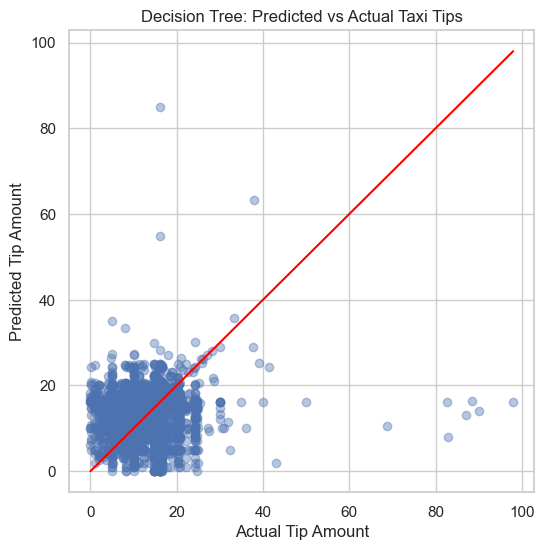

In [ ]:
# TODO: Import, initialise, and train a regression model.
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

#   Start simple (LinearRegression), then try a more flexible model
#   (e.g. RandomForestRegressor or DecisionTreeRegressor) and compare.
linear_model = LinearRegression()
tree_model = DecisionTreeRegressor(random_state=RANDOM_STATE)


# TODO: Predict on train, validation, and test sets.
linear_model.fit(x_taxi_train_scaled, y_taxi_train)
tree_model.fit(x_taxi_train_scaled, y_taxi_train)

linear_train_pred = linear_model.predict(x_taxi_train_scaled)
linear_val_pred = linear_model.predict(x_taxi_val_scaled)
linear_test_pred = linear_model.predict(x_taxi_test_scaled)

tree_train_pred = tree_model.predict(x_taxi_train_scaled)
tree_val_pred = tree_model.predict(x_taxi_val_scaled)
tree_test_pred = tree_model.predict(x_taxi_test_scaled)

# TODO: Report RMSE and R^2 for ALL THREE sets.
#   from sklearn.metrics import mean_squared_error, r2_score
#   (RMSE = mean_squared_error(y_true, y_pred) ** 0.5)


def evaluate_model(y_true, y_pred, model_name, dataset_name):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)

    print(model_name, "-", dataset_name)
    print("RMSE:", rmse)
    print("R^2:", r2)
    print()


evaluate_model(y_taxi_train, linear_train_pred, "Linear Regression", "Training Set")
evaluate_model(y_taxi_val, linear_val_pred, "Linear Regression", "Validation Set")
evaluate_model(y_taxi_test, linear_test_pred, "Linear Regression", "Test Set")

evaluate_model(y_taxi_train, tree_train_pred, "Decision Tree", "Training Set")
evaluate_model(y_taxi_val, tree_val_pred, "Decision Tree", "Validation Set")
evaluate_model(y_taxi_test, tree_test_pred, "Decision Tree", "Test Set")

# TODO: Plot predicted vs actual tip for the test set (a scatter with the y=x line).
plt.figure(figsize=(6, 6))

plt.scatter(y_taxi_test, tree_test_pred, alpha=0.4)

plt.xlabel("Actual Tip Amount")
plt.ylabel("Predicted Tip Amount")
plt.title("Decision Tree: Predicted vs Actual Taxi Tips")

min_tip = min(y_taxi_test.min(), tree_test_pred.min())
max_tip = max(y_taxi_test.max(), tree_test_pred.max())

plt.plot([min_tip, max_tip], [min_tip, max_tip], color="red")

plt.show()


**Student Reasoning — Regression evaluation & overfitting**
_1. Which model performed best on the validation set, and which hyper-parameters did you try?_
_2. Compare TRAIN vs VALIDATION vs TEST metrics. Is the model overfitting, underfitting, or
well-fitted? Quote the specific numbers that back up your claim._
_3. What would you change to reduce overfitting if you saw it?_

> **Answer:** [Double-click to edit]


---

# Section 2 — Supervised Learning: Multi-class Classification

## Predicting obesity level (`NObeyesdad`)

Each row describes a person's eating habits and physical condition. Predict their
**obesity category** `NObeyesdad`, which has **7 classes**: `Insufficient_Weight, Normal_Weight,
Overweight_Level_I, Overweight_Level_II, Obesity_Type_I, Obesity_Type_II, Obesity_Type_III`.

Feature columns: `Gender, Age, Height, Weight, family_history_with_overweight, FAVC, FCVC, NCP,
CAEC, SMOKE, CH2O, SCC, FAF, TUE, CALC, MTRANS`.


### Part 2.1 — Load and explore the obesity data

Look at the shape, dtypes, missing values, and especially the **class balance** of the target.


Obesity shape: (2111, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II



Obesity info:
<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                           

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000



Missing values per column:


Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64


Class distribution:


NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64

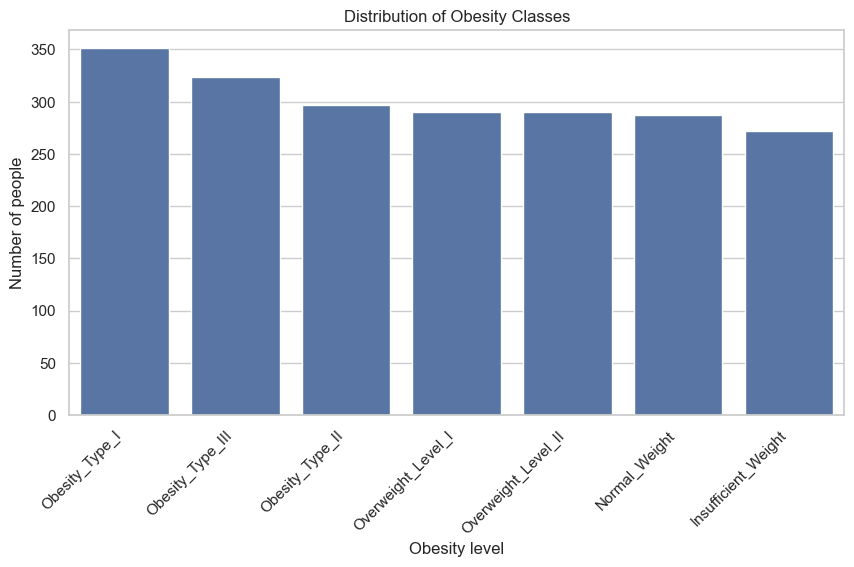

In [ ]:
# TODO: Load the obesity dataset from OBESITY_URL into a DataFrame called `obesity`
obesity = pd.read_csv(
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
)

# TODO: Inspect shape, head, info, describe, and missing values.
print("Obesity shape:", obesity.shape)
display(obesity.head())

print("\nObesity info:")
obesity.info()

print("\nSummary statistics:")
display(obesity.describe())

print("\nMissing values per column:")
display(obesity.isna().sum())

# TODO: Show the class distribution of `NObeyesdad`
print("\nClass distribution:")
display(obesity["NObeyesdad"].value_counts())

plt.figure(figsize=(10, 5))
sns.countplot(
    data=obesity, x="NObeyesdad", order=obesity["NObeyesdad"].value_counts().index
)
plt.title("Distribution of Obesity Classes")
plt.xlabel("Obesity level")
plt.ylabel("Number of people")
plt.xticks(rotation=45, ha="right")
plt.show()

#   (value_counts and a sns.countplot). Is it balanced across the 7 classes?


**Student Reasoning — Obesity data exploration**
_How many rows/features are there? Which columns are categorical vs numeric? Is the target
balanced across the 7 classes, and why does class (im)balance matter for classification?_

> **Answer:** [Double-click to edit]


### Part 2.2 — Preprocessing & feature engineering

Models need numeric input. Encode categoricals, scale numerics, and optionally add a feature.


In [ ]:
from sklearn.preprocessing import LabelEncoder
# TODO: Encode categorical columns.
#   - Binary yes/no columns (family_history_with_overweight, FAVC, SMOKE, SCC) -> 0/1
#   - Ordinal-ish columns (CAEC, CALC) and nominal (Gender, MTRANS) -> choose an encoding
#     and justify it (LabelEncoder / OrdinalEncoder / pd.get_dummies / OneHotEncoder).

# TODO (optional but encouraged): engineer a domain feature, e.g. BMI = Weight / Height**2.
#   Discuss whether including BMI makes the task "too easy" / leaks the target.
obesity_cleaned = obesity.copy().dropna()

obesity_cleaned["BMI"] = obesity_cleaned["Weight"] / (obesity_cleaned["Height"] ** 2)

x_obesity_raw = obesity_cleaned.drop(columns=["NObeyesdad"]).copy()
y_obesity_raw = obesity_cleaned["NObeyesdad"].copy()

obesity_binary_cols = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]
yes_no_map = {"yes": 1, "no": 0}
for col in obesity_binary_cols:
    x_obesity_raw[col] = x_obesity_raw[col].map(yes_no_map)


obesity_numeric_cols = [
    "Age",
    "Height",
    "Weight",
    "FCVC",
    "NCP",
    "CH2O",
    "FAF",
    "TUE",
    "BMI",
] + obesity_binary_cols

obesity_categorical_cols = ["Gender", "CAEC", "CALC", "MTRANS"]
x_obesity = pd.get_dummies(
    x_obesity_raw[obesity_numeric_cols + obesity_categorical_cols],
    columns=obesity_categorical_cols,
    drop_first=False,
)
# TODO: Encode the target `NObeyesdad` into integer class labels
#   from sklearn.preprocessing import LabelEncoder


obesity_target_encoder = LabelEncoder()
y_obesity = obesity_target_encoder.fit_transform(y_obesity_raw)

# TODO: Scale the numeric features (fit on TRAIN only, in Part 2.3).


**Student Reasoning — Obesity preprocessing**
_1. How did you encode each type of categorical variable, and why?_
_2. Did you engineer any feature (e.g. BMI)? Argue whether it is fair to include given the
target is an obesity level._
_3. Which scaler did you use and why?_

> **Answer:** [Double-click to edit]


### Part 2.3 — Stratified Train / Validation / Test split

With 7 (possibly imbalanced) classes, stratification keeps the class proportions in each split.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# TODO: Separate X (features) and y (encoded NObeyesdad).
# TODO: Split into train / validation / test using stratify=y so every split has all 7 classes.
#   Use random_state=RANDOM_STATE.
x_obesity_train_val, x_obesity_test, y_obesity_train_val, y_obesity_test = (
    train_test_split(
        x_obesity,
        y_obesity,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y_obesity,
    )
)

x_obesity_train, x_obesity_val, y_obesity_train, y_obesity_val = train_test_split(
    x_obesity_train_val,
    y_obesity_train_val,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_obesity_train_val,
)

# TODO: Fit the scaler on the training set only, then transform train / val / test.
obesity_scaler = StandardScaler()

x_obesity_train_scaled = x_obesity_train.copy()
x_obesity_val_scaled = x_obesity_val.copy()
x_obesity_test_scaled = x_obesity_test.copy()

x_obesity_train_scaled[obesity_numeric_cols] = obesity_scaler.fit_transform(
    x_obesity_train[obesity_numeric_cols]
)
x_obesity_val_scaled[obesity_numeric_cols] = obesity_scaler.transform(
    x_obesity_val[obesity_numeric_cols]
)
x_obesity_test_scaled[obesity_numeric_cols] = obesity_scaler.transform(
    x_obesity_test[obesity_numeric_cols]
)

print("Train shape:", x_obesity_train_scaled.shape)
print("Validation shape:", x_obesity_val_scaled.shape)
print("Test shape:", x_obesity_test_scaled.shape)

print("\nClass counts in train:")
display(pd.Series(y_obesity_train).value_counts().sort_index())

print("\nClass counts in validation:")
display(pd.Series(y_obesity_val).value_counts().sort_index())

print("\nClass counts in test:")
display(pd.Series(y_obesity_test).value_counts().sort_index())


Train shape: (1266, 28)
Validation shape: (422, 28)
Test shape: (423, 28)

Class counts in train:


0    163
1    172
2    211
3    178
4    194
5    174
6    174
Name: count, dtype: int64


Class counts in validation:


0    55
1    57
2    70
3    59
4    65
5    58
6    58
Name: count, dtype: int64


Class counts in test:


0    54
1    58
2    70
3    60
4    65
5    58
6    58
Name: count, dtype: int64

**Student Reasoning — Splitting**
_What split ratio did you choose? Why is `stratify=y` important for this dataset?
What could go wrong if you split without stratifying?_

> **Answer:** [Double-click to edit]


### Part 2.4 — Train a classifier and check for overfitting

Train a multi-class classifier and evaluate it on **train, validation, and test**.


In [ ]:
# TODO: Import, initialise, and train a classifier
#   (e.g. LogisticRegression(max_iter=...), RandomForestClassifier, or KNeighborsClassifier).
from sklearn.neighbors import KNeighborsClassifier


knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_obesity_train_scaled, y_obesity_train)

# TODO: Predict on train, validation, and test.

knn_train_pred = knn_model.predict(x_obesity_train_scaled)
knn_val_pred = knn_model.predict(x_obesity_val_scaled)
knn_test_pred = knn_model.predict(x_obesity_test_scaled)


# TODO: Report accuracy AND macro-F1 for ALL THREE sets
#   from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)


def evaluate_classifier(y_true, y_pred, dataset_name):
    accuracy = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")

    print(dataset_name)
    print("Accuracy:", accuracy)
    print("Macro-F1:", macro_f1)
    print()


evaluate_classifier(y_obesity_train, knn_train_pred, "Training Set")
evaluate_classifier(y_obesity_val, knn_val_pred, "Validation Set")
evaluate_classifier(y_obesity_test, knn_test_pred, "Test Set")

print("Classification Report - Test Set")
print(
    classification_report(
        y_obesity_test, knn_test_pred, target_names=obesity_target_encoder.classes_
    )
)


# TODO: Show a confusion matrix for the test set
#   from sklearn.metrics import ConfusionMatrixDisplay
#   Which classes are most often confused?


Training Set
Accuracy: 0.8751974723538705
Macro-F1: 0.8671877142011176

Validation Set
Accuracy: 0.8483412322274881
Macro-F1: 0.8316806212264403

Test Set
Accuracy: 0.8416075650118203
Macro-F1: 0.8322271969142191

Classification Report - Test Set
                     precision    recall  f1-score   support

Insufficient_Weight       0.76      0.94      0.84        54
      Normal_Weight       0.75      0.57      0.65        58
     Obesity_Type_I       0.80      0.93      0.86        70
    Obesity_Type_II       0.94      0.97      0.95        60
   Obesity_Type_III       1.00      1.00      1.00        65
 Overweight_Level_I       0.81      0.66      0.72        58
Overweight_Level_II       0.81      0.79      0.80        58

           accuracy                           0.84       423
          macro avg       0.84      0.84      0.83       423
       weighted avg       0.84      0.84      0.84       423



**Student Reasoning — Classification evaluation & overfitting**
_1. Which classifier did you choose and why?_
_2. Compare TRAIN vs VALIDATION vs TEST accuracy/F1. Is the model overfitting, underfitting,
or well-fitted? Cite the specific metrics._
_3. From the confusion matrix, which obesity levels are hardest to tell apart, and why might
that be?_

> **Answer:** [Double-click to edit]


---

# Section 3 — Unsupervised Learning: K-Means Clustering

## Discovering hidden groups in the obesity data

Now **pretend you never had the `NObeyesdad` labels.** Using only the _scaled feature matrix_
from Section 2, use **K-Means** to see whether people naturally fall into distinct profiles —
and then compare those clusters to the real obesity levels.


### Part 3.1 — Choose k, fit K-Means, and visualise


,k,inertia,silhouette
0,2,26484.437695,0.185977
1,3,24422.497071,0.196954
2,4,22450.051873,0.119776
3,5,20667.269832,0.139154
4,6,19276.367979,0.154469
5,7,17964.544798,0.165736
6,8,16666.226832,0.168772
7,9,15846.695271,0.175632
8,10,15320.477069,0.177861


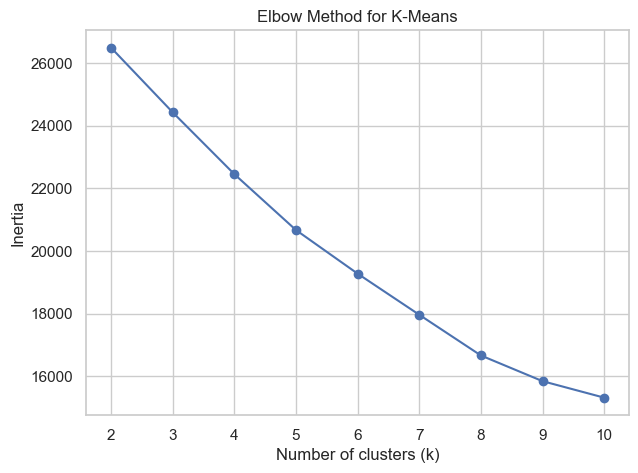

Chosen k: 3


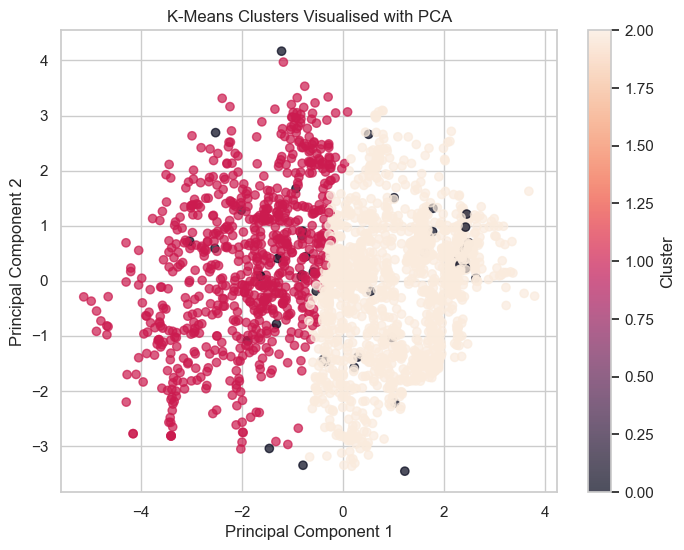

In [ ]:
# TODO: Use ONLY the scaled obesity features (no target) for clustering.

# TODO: Choose the number of clusters k with the Elbow method (and/or silhouette score).
#   from sklearn.cluster import KMeans
#   from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

obesity_cluster_scaler = StandardScaler()  # from part 2.3
x_obesity_scaled_all = x_obesity.copy()
x_obesity_scaled_all[obesity_numeric_cols] = obesity_cluster_scaler.fit_transform(
    x_obesity[obesity_numeric_cols]
)

x_cluster = x_obesity_scaled_all.copy()
#   Loop k = 2..10, record inertia_ (and silhouette), and plot inertia vs k.
k_values = range(2, 11)
inertias = []
silhouettes = []

# TODO: Fit KMeans with your chosen k (random_state=RANDOM_STATE) and get cluster labels.


for k in k_values:
    kmeans_temp = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    temp_labels = kmeans_temp.fit_predict(x_cluster)
    inertias.append(kmeans_temp.inertia_)
    silhouettes.append(
        silhouette_score(
            x_cluster,
            temp_labels,
            sample_size=min(1000, len(x_cluster)),
            random_state=RANDOM_STATE,
        )
    )

possible_k = pd.DataFrame(
    {"k": list(k_values), "inertia": inertias, "silhouette": silhouettes}
)

display(possible_k)

# k-elbow graph
plt.figure(figsize=(7, 5))
plt.plot(possible_k["k"], possible_k["inertia"], marker="o")
plt.title("Elbow Method for K-Means")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.show()


chosen_k = int(possible_k.loc[possible_k["silhouette"].idxmax(), "k"])
print("Chosen k:", chosen_k)

kmeans = KMeans(n_clusters=chosen_k, random_state=RANDOM_STATE, n_init=10)

# TODO: Visualise the clusters in 2D.
#   Pick two informative features (e.g. Weight vs Height) OR reduce to 2D with PCA
#   (from sklearn.decomposition import PCA) and colour points by cluster.
from sklearn.decomposition import PCA

cluster_labels = kmeans.fit_predict(x_cluster)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
cluster_points_2d = pca.fit_transform(x_cluster)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    cluster_points_2d[:, 0], cluster_points_2d[:, 1], c=cluster_labels, alpha=0.7
)
plt.title("K-Means Clusters Visualised with PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(scatter, label="Cluster")
plt.show()


In [ ]:
# TODO: How well do the clusters line up with the TRUE obesity levels?
#   Build a crosstab of cluster label vs the real NObeyesdad category:
#   pd.crosstab(cluster_labels, obesity['NObeyesdad'])
#   Do some clusters map cleanly onto specific obesity levels?


**Student Reasoning — Clustering**
_1. How did you choose k? Quote the Elbow/silhouette evidence._
_2. Looking at the crosstab, do the unsupervised clusters resemble the real obesity levels?
Where do they agree and where do they break down?_
_3. In a real public-health setting where labels are expensive to collect, what would these
clusters be useful for?_

> **Answer:** [Double-click to edit]


---

# Section 4 — Reflection

_Answer in a few sentences each:_

1. **Supervised vs unsupervised:** What did the classifier learn that K-Means could not, and
   vice-versa?
   The classifier was able to map characteristics of datapoints to an output but K-means could only group like terms in a dataset. Therefore the classifier is able to learn the most probable outcome with a given input while the k-means can uncover unforeseen patterns in data.

2. **Regression vs classification:** How did evaluating a continuous target (tips) differ from
   evaluating a categorical one (obesity level)?
   For regression models, RMSE and r**2 were used to evaluate bias and variance of the trained model respectively. R**2 displayed how far the prediction is from the correct answer. RMSE shows the differences between datapoints in a dataset.

3. **Overfitting:** Across all three tasks, where did you see the biggest train-vs-test gap, and
   what is the single most effective thing you did (or would do) to close it?
   The biggest train-vs-test gap shows in the decision tree model. The training r**2 shows a good amount of variance(0.77). However in the test it r**2 = -0.64 which shows that its prediction is worse than if it were to predict that the result would be the average of the labels of the data it was trained on. Therefore the decision tree model memorised the data it was trained on to produce output.

> **Answer:** [Double-click to edit]


---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel → Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook.
- [ ] Notebook committed and pushed to your `lab-2-predictive-analytics` repository.
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository

---

#### Grading guide (100 pts)

| Area                                                                                | Pts |
| ----------------------------------------------------------------------------------- | --- |
| Section 1 — Regression (load, preprocess, split, model, overfitting)                | 30  |
| Section 2 — Classification (load, preprocess, stratified split, model, overfitting) | 30  |
| Section 3 — K-Means clustering (k selection, fit, visualise, compare)               | 20  |
| Reasoning boxes & Section 4 reflection                                              | 15  |
| Reproducibility (runs clean, random_state, tidy code)                               | 5   |
